# Bellabeat Smart Device Usage & Wellness Behaviour Analysis

## Stage 4: Analyze

### Analysis Objective

The purpose of this stage is to explore the cleaned Fitbit datasets and identify meaningful patterns in users' activity and sleep behaviour.

The analysis will focus on:

- Daily step patterns
- Activity intensity
- Sedentary behaviour
- Calories burned
- Daily and weekly activity trends
- Sleep duration
- Time spent in bed
- Relationships between sleep and physical activity
- Behavioural differences across users

The findings from this stage will be used to answer the business questions and support high-level recommendations for Bellabeat.

In [1]:
import pandas as pd

In [2]:
daily_activity = pd.read_csv(
    "../data/processed/daily_activity_clean.csv",
    parse_dates=["ActivityDate"]
)

sleep_day = pd.read_csv(
    "../data/processed/sleep_day_clean.csv",
    parse_dates=["SleepDay"]
)

In [3]:
print("Daily activity shape:", daily_activity.shape)
print("Sleep data shape:", sleep_day.shape)

Daily activity shape: (936, 15)
Sleep data shape: (410, 5)


In [4]:
daily_activity[
    [
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "Calories"
    ]
].describe()

,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,936.000000,936.000000,936.000000,936.000000,936.000000,936.000000,936.000000
mean,7670.551282,5.513162,21.255342,13.622863,193.636752,989.292735,2313.454060
std,5073.379140,3.916497,32.885736,20.010368,108.675578,300.474654,703.683874
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.000000
25%,3818.000000,2.645000,0.000000,0.000000,128.000000,729.000000,1834.000000
50%,7441.000000,5.265000,4.000000,7.000000,199.000000,1057.000000,2144.000000
75%,10733.500000,7.720000,32.000000,19.000000,264.250000,1226.000000,2794.500000
max,36019.000000,28.030001,210.000000,143.000000,518.000000,1440.000000,4900.000000


In [5]:
daily_activity.sort_values(
    by="Calories"
).head(10)[
    [
        "Id",
        "ActivityDate",
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "Calories"
    ]
]

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
344,3977333714,2016-05-11,746,0.50,4,0,9,13,52
904,8792009665,2016-05-10,0,0.00,0,0,0,48,57
734,7007744171,2016-05-07,0,0.00,0,0,0,111,120
410,4319703577,2016-05-12,17,0.01,0,0,2,0,257
263,2347167796,2016-04-29,42,0.03,0,0,4,2,403
121,1844505072,2016-05-12,0,0.00,0,0,0,711,665
565,5553957443,2016-05-12,3121,2.04,8,6,48,222,741
708,6962181067,2016-05-12,3587,2.37,0,8,105,127,928
60,1624580081,2016-05-12,2971,1.93,0,0,107,890,1002
677,6775888955,2016-05-07,1967,1.41,2,5,49,551,1032


In [6]:
daily_activity["TotalTrackedMinutes"] = (
    daily_activity["VeryActiveMinutes"]
    + daily_activity["FairlyActiveMinutes"]
    + daily_activity["LightlyActiveMinutes"]
    + daily_activity["SedentaryMinutes"]
)

In [7]:
daily_activity["TotalTrackedMinutes"].describe()

count     936.000000
mean     1217.807692
std       266.105133
min         2.000000
25%       989.000000
50%      1440.000000
75%      1440.000000
max      1440.000000
Name: TotalTrackedMinutes, dtype: float64

In [8]:
print(
    "Less than 60 minutes:",
    (daily_activity["TotalTrackedMinutes"] < 60).sum()
)

print(
    "Less than 600 minutes:",
    (daily_activity["TotalTrackedMinutes"] < 600).sum()
)

print(
    "Less than 960 minutes:",
    (daily_activity["TotalTrackedMinutes"] < 960).sum()
)

print(
    "Full 1440-minute days:",
    (daily_activity["TotalTrackedMinutes"] == 1440).sum()
)

Less than 60 minutes: 4
Less than 600 minutes: 15
Less than 960 minutes: 180
Full 1440-minute days: 474


In [9]:
daily_activity["ValidActivityDay"] = (
    daily_activity["TotalTrackedMinutes"] >= 960
)

In [10]:
daily_activity["ValidActivityDay"].value_counts()

ValidActivityDay
True     756
False    180
Name: count, dtype: int64

In [11]:
valid_activity = daily_activity[
    daily_activity["ValidActivityDay"]
].copy()

In [12]:
valid_activity.shape

(756, 17)

In [13]:
valid_activity[
    [
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "Calories"
    ]
].describe()

,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,7801.142857,5.627989,22.298942,13.751323,191.208995,1082.775132,2355.277778
std,5220.200979,4.047741,32.093498,19.926595,109.776528,245.156411,658.281407
min,0.000000,0.000000,0.000000,0.000000,0.000000,468.000000,1002.000000
25%,3958.500000,2.680000,0.000000,0.000000,121.750000,840.750000,1881.500000
50%,7708.500000,5.350000,6.000000,7.000000,202.000000,1121.000000,2178.000000
75%,10994.500000,7.845000,36.000000,20.000000,263.250000,1265.000000,2806.750000
max,36019.000000,28.030001,207.000000,143.000000,518.000000,1440.000000,4547.000000


In [14]:
valid_activity

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalTrackedMinutes,ValidActivityDay
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985,1094,True
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797,1033,True
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776,1440,True
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745,998,True
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863,1040,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930,8877689391,2016-05-07,12332,8.130000,8.130000,0.0,0.08,0.96,6.99,0.00,105,28,271,1036,4142,1440,True
931,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847,1440,True
932,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710,1440,True
933,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832,1440,True


### Activity Data Completeness

To reduce the influence of severely incomplete tracking days, total tracked minutes were calculated as the sum of:

- Very active minutes
- Fairly active minutes
- Lightly active minutes
- Sedentary minutes

A complete day contains 1,440 minutes.

The dataset contained:

- 4 days with fewer than 60 tracked minutes
- 15 days with fewer than 600 tracked minutes
- 180 days with fewer than 960 tracked minutes
- 474 fully recorded 1,440-minute days

For this analysis, a project-defined threshold of at least 960 tracked minutes (16 hours) was used to identify sufficiently complete activity days.

This resulted in 756 valid activity-day records.

The 960-minute threshold is an analytical decision for this project and is not presented as an official Fitbit or Bellabeat standard.

Using the valid activity days produced slightly higher estimates for average steps, activity minutes, calories and sedentary time, indicating that incomplete tracking days were affecting the original descriptive statistics.

In [15]:
average_activity = valid_activity[
    [
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "Calories"
    ]
].mean().round(2)

average_activity

TotalSteps              7801.14
TotalDistance              5.63
VeryActiveMinutes         22.30
FairlyActiveMinutes       13.75
LightlyActiveMinutes     191.21
SedentaryMinutes        1082.78
Calories                2355.28
dtype: float64

### Average Daily Activity

Across the 756 valid activity-day records, users averaged approximately:

- 7,801 steps per day
- 5.63 units of total distance
- 22.30 minutes of very active activity
- 13.75 minutes of fairly active activity
- 191.21 minutes of light activity
- 1,082.78 minutes of sedentary time
- 2,355 calories burned

The results indicate that light activity accounted for substantially more recorded active time than moderate or very active activity.

Average sedentary time was approximately 1,083 minutes, equivalent to about 18 hours per day.

These findings suggest that although users accumulated meaningful daily activity, a large proportion of recorded time was sedentary.

In [16]:
valid_activity["DayOfWeek"] = valid_activity["ActivityDate"].dt.day_name()

In [17]:
weekday_activity = (
    valid_activity.groupby("DayOfWeek")
    .agg(
        AverageSteps=("TotalSteps", "mean"),
        AverageCalories=("Calories", "mean"),
        AverageVeryActiveMinutes=("VeryActiveMinutes", "mean"),
        AverageSedentaryMinutes=("SedentaryMinutes", "mean")
    )
    .round(2)
)

weekday_activity

,AverageSteps,AverageCalories,AverageVeryActiveMinutes,AverageSedentaryMinutes
DayOfWeek,,,,
Friday,7608.96,2393.14,22.27,1058.03
Monday,7749.81,2348.48,23.90,1093.83
Saturday,8195.31,2379.92,22.72,1090.32
Sunday,6626.60,2231.50,16.79,1170.28
Thursday,8040.14,2372.26,23.18,1054.81
Tuesday,8256.52,2371.66,23.07,1057.74
Wednesday,7792.56,2357.47,22.69,1084.55


In [18]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_activity = weekday_activity.reindex(day_order)

weekday_activity

,AverageSteps,AverageCalories,AverageVeryActiveMinutes,AverageSedentaryMinutes
DayOfWeek,,,,
Monday,7749.81,2348.48,23.90,1093.83
Tuesday,8256.52,2371.66,23.07,1057.74
Wednesday,7792.56,2357.47,22.69,1084.55
Thursday,8040.14,2372.26,23.18,1054.81
Friday,7608.96,2393.14,22.27,1058.03
Saturday,8195.31,2379.92,22.72,1090.32
Sunday,6626.60,2231.50,16.79,1170.28


In [19]:
most_active_day = weekday_activity["AverageSteps"].idxmax()
least_active_day = weekday_activity["AverageSteps"].idxmin()

print("Most active day:", most_active_day)
print("Least active day:", least_active_day)

Most active day: Tuesday
Least active day: Sunday


### Weekday Activity Patterns

Average daily steps varied across the week.

- Tuesday had the highest average step count at approximately 8,257 steps.
- Saturday was also relatively active, with approximately 8,195 average steps.
- Sunday had the lowest average step count at approximately 6,627 steps.
- Sunday also recorded the highest average sedentary time at approximately 1,170 minutes.

These results suggest that user activity was generally lower on Sundays compared with other days of the week, while Tuesdays and Saturdays showed stronger activity levels.

This pattern may be useful when considering the timing of Bellabeat app prompts, activity challenges or engagement campaigns.

In [20]:
steps_calories_corr = valid_activity[
    ["TotalSteps", "Calories"]
].corr()

steps_calories_corr

,TotalSteps,Calories
TotalSteps,1.000000,0.576525
Calories,0.576525,1.000000


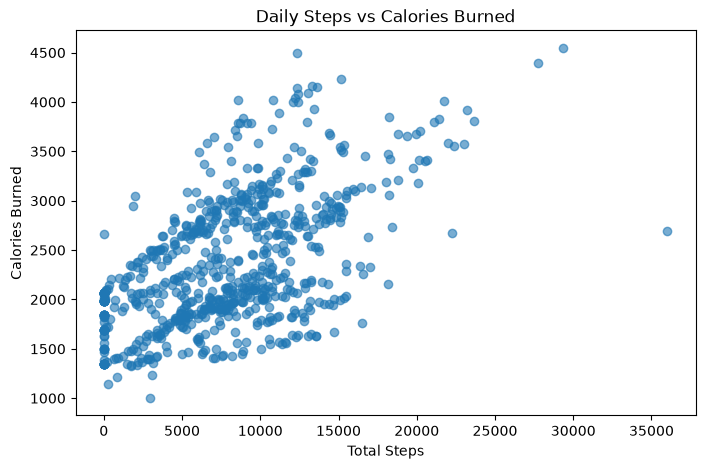

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    valid_activity["TotalSteps"],
    valid_activity["Calories"],
    alpha=0.6
)

plt.title("Daily Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")

plt.show()

### Relationship Between Daily Steps and Calories Burned

Daily steps and calories burned showed a moderate positive correlation of approximately 0.58.

The scatter plot indicates that days with higher step counts generally tended to have higher calorie expenditure.

However, the relationship was not perfect. Users with similar daily step counts sometimes recorded substantially different calorie totals, suggesting that factors other than step count may also influence calorie expenditure, including activity intensity and individual differences.

Because the dataset contains repeated observations from the same Fitbit users, this relationship should be interpreted as descriptive rather than causal.

In [22]:
user_activity = (
    valid_activity.groupby("Id")
    .agg(
        AverageDailySteps=("TotalSteps", "mean"),
        AverageDailyCalories=("Calories", "mean"),
        AverageVeryActiveMinutes=("VeryActiveMinutes", "mean"),
        AverageSedentaryMinutes=("SedentaryMinutes", "mean"),
        ValidDays=("ActivityDate", "count")
    )
    .round(2)
)

user_activity.head(10)

,AverageDailySteps,AverageDailyCalories,AverageVeryActiveMinutes,AverageSedentaryMinutes,ValidDays
Id,,,,,
1503960366,12709.07,1887.18,39.93,847.86,28
1624580081,5743.90,1483.35,8.68,1257.74,31
1644430081,7621.50,2874.39,10.21,1195.04,28
1844505072,2575.96,1595.70,0.15,1309.78,27
1927972279,924.07,2171.23,1.37,1336.87,30
2022484408,11370.65,2509.97,36.29,1112.58,31
2026352035,4196.71,1462.71,0.00,950.43,7
2320127002,4785.40,1744.13,1.40,1233.10,30
2347167796,11088.50,2217.80,17.10,791.30,10


In [23]:
user_activity["ValidDays"].describe()

count    33.000000
mean     22.909091
std       7.337249
min       4.000000
25%      18.000000
50%      24.000000
75%      29.000000
max      31.000000
Name: ValidDays, dtype: float64

In [24]:
print(
    "Users with at least 7 valid days:",
    (user_activity["ValidDays"] >= 7).sum()
)

print(
    "Users with at least 14 valid days:",
    (user_activity["ValidDays"] >= 14).sum()
)

print(
    "Users with at least 21 valid days:",
    (user_activity["ValidDays"] >= 21).sum()
)

Users with at least 7 valid days: 32
Users with at least 14 valid days: 29
Users with at least 21 valid days: 20


In [25]:
user_activity_filtered = user_activity[
    user_activity["ValidDays"] >= 14
].copy()

In [26]:
user_activity_filtered.shape

(29, 5)

In [27]:
user_activity_filtered["AverageDailySteps"].describe()

count       29.000000
mean      7888.700690
std       3941.260112
min        924.070000
25%       5743.900000
50%       7555.770000
75%      10835.830000
max      16305.900000
Name: AverageDailySteps, dtype: float64

In [28]:
q1 = user_activity_filtered["AverageDailySteps"].quantile(0.25)
q3 = user_activity_filtered["AverageDailySteps"].quantile(0.75)

user_activity_filtered["ActivityLevel"] = pd.cut(
    user_activity_filtered["AverageDailySteps"],
    bins=[float("-inf"), q1, q3, float("inf")],
    labels=["Low Activity", "Moderate Activity", "High Activity"],
    include_lowest=True
)

In [29]:
user_activity_filtered["ActivityLevel"].value_counts()

ActivityLevel
Moderate Activity    14
Low Activity          8
High Activity         7
Name: count, dtype: int64

In [30]:
activity_group_summary = (
    user_activity_filtered.groupby(
        "ActivityLevel",
        observed=False
    )
    .agg(
        AverageSteps=("AverageDailySteps", "mean"),
        AverageCalories=("AverageDailyCalories", "mean"),
        AverageVeryActiveMinutes=("AverageVeryActiveMinutes", "mean"),
        AverageSedentaryMinutes=("AverageSedentaryMinutes", "mean"),
        Users=("AverageDailySteps", "count")
    )
    .round(2)
)

activity_group_summary

,AverageSteps,AverageCalories,AverageVeryActiveMinutes,AverageSedentaryMinutes,Users
ActivityLevel,,,,,
Low Activity,3161.74,1971.92,4.41,1226.11,8
Moderate Activity,8076.98,2581.37,24.17,1015.81,14
High Activity,12914.37,2447.28,45.53,982.95,7


### User Activity Segmentation

For user-level analysis, only participants with at least 14 valid activity days were included. This resulted in 29 users.

Users were segmented according to the distribution of their average daily steps:

- **Low Activity:** below the 25th percentile
- **Moderate Activity:** between the 25th and 75th percentiles
- **High Activity:** above the 75th percentile

These categories are specific to this dataset and should not be interpreted as official health or Fitbit activity classifications.

The analysis identified:

- 8 Low Activity users
- 14 Moderate Activity users
- 7 High Activity users

Average daily steps increased substantially across the three groups, from approximately 3,162 steps among Low Activity users to 12,914 steps among High Activity users.

High Activity users also recorded considerably more very active time, averaging approximately 45.5 minutes per day compared with only 4.4 minutes among Low Activity users.

Average sedentary time decreased as activity level increased. Low Activity users recorded approximately 1,226 sedentary minutes per day, compared with approximately 983 minutes among High Activity users.

Average calorie expenditure did not increase consistently across the activity groups. Moderate Activity users recorded a higher average calorie expenditure than High Activity users, indicating that step count alone does not explain differences in calorie expenditure.

In [31]:
sleep_summary = sleep_day[
    [
        "TotalMinutesAsleep",
        "TotalTimeInBed"
    ]
].describe()

sleep_summary

,TotalMinutesAsleep,TotalTimeInBed
count,410.000000,410.000000
mean,419.173171,458.482927
std,118.635918,127.455140
min,58.000000,61.000000
25%,361.000000,403.750000
50%,432.500000,463.000000
75%,490.000000,526.000000
max,796.000000,961.000000


In [32]:
sleep_day["SleepEfficiency"] = (
    sleep_day["TotalMinutesAsleep"]
    / sleep_day["TotalTimeInBed"]
) * 100

In [33]:
sleep_day["SleepEfficiency"].describe().round(2)

count    410.00
mean      91.65
std        8.73
min       49.84
25%       91.18
50%       94.26
75%       96.06
max      100.00
Name: SleepEfficiency, dtype: float64

### Sleep Behaviour

The cleaned sleep dataset contained 410 daily sleep records from 24 Fitbit users.

Across these records:

- Average sleep duration was approximately 419 minutes per night.
- Median sleep duration was approximately 433 minutes.
- Average time in bed was approximately 458 minutes.
- The shortest recorded sleep period was 58 minutes.
- The longest recorded sleep period was 796 minutes.

Sleep efficiency was calculated as:

`TotalMinutesAsleep / TotalTimeInBed × 100`

Average sleep efficiency was approximately 91.65%, while the median was 94.26%.

Sleep efficiency varied substantially across records, with values ranging from approximately 49.84% to 100%.

These results describe patterns in the available Fitbit records and should not be interpreted as clinical assessments of sleep quality.

In [34]:
sleep_day["DayOfWeek"] = sleep_day["SleepDay"].dt.day_name()

In [35]:
sleep_weekday = (
    sleep_day.groupby("DayOfWeek")
    .agg(
        AverageSleepMinutes=("TotalMinutesAsleep", "mean"),
        AverageTimeInBed=("TotalTimeInBed", "mean"),
        AverageSleepEfficiency=("SleepEfficiency", "mean")
    )
    .round(2)
)

sleep_weekday

,AverageSleepMinutes,AverageTimeInBed,AverageSleepEfficiency
DayOfWeek,,,
Friday,405.42,445.05,92.01
Monday,419.50,457.35,91.97
Saturday,419.07,459.84,91.50
Sunday,452.75,503.51,90.51
Thursday,401.30,434.88,92.27
Tuesday,404.54,443.29,91.09
Wednesday,434.68,470.03,92.13


In [36]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sleep_weekday = sleep_weekday.reindex(day_order)

sleep_weekday

,AverageSleepMinutes,AverageTimeInBed,AverageSleepEfficiency
DayOfWeek,,,
Monday,419.50,457.35,91.97
Tuesday,404.54,443.29,91.09
Wednesday,434.68,470.03,92.13
Thursday,401.30,434.88,92.27
Friday,405.42,445.05,92.01
Saturday,419.07,459.84,91.50
Sunday,452.75,503.51,90.51


### Sleep Patterns by Day of Week

Average sleep duration varied across the week.

- Sunday had the highest average sleep duration at approximately 453 minutes, equivalent to about 7 hours and 33 minutes.
- Wednesday had the second-highest average sleep duration at approximately 435 minutes.
- Thursday had the lowest average sleep duration at approximately 401 minutes, equivalent to about 6 hours and 41 minutes.
- Sunday also had the longest average time in bed at approximately 504 minutes.
- Average sleep efficiency remained relatively stable across the week, ranging from approximately 90.5% to 92.3%.

These results suggest that users tended to sleep longer on Sundays than on most weekdays.

This pattern may be relevant for Bellabeat when considering the timing of sleep-related reminders, recovery messaging or weekend wellness content.

In [37]:
sleep_activity = pd.merge(
    valid_activity,
    sleep_day,
    left_on=["Id", "ActivityDate"],
    right_on=["Id", "SleepDay"],
    how="inner"
)

In [38]:
sleep_activity.shape

(241, 24)

In [39]:
sleep_activity["Id"].nunique()

23

In [40]:
matched_records_per_user = sleep_activity.groupby("Id").size()

print("Minimum matched records for one user:", matched_records_per_user.min())
print("Maximum matched records for one user:", matched_records_per_user.max())

Minimum matched records for one user: 1
Maximum matched records for one user: 23


In [41]:
print(
    "Users with at least 3 matched days:",
    (matched_records_per_user >= 3).sum()
)

print(
    "Users with at least 7 matched days:",
    (matched_records_per_user >= 7).sum()
)

print(
    "Users with at least 14 matched days:",
    (matched_records_per_user >= 14).sum()
)

Users with at least 3 matched days: 20
Users with at least 7 matched days: 15
Users with at least 14 matched days: 9


In [42]:
eligible_sleep_users = matched_records_per_user[
    matched_records_per_user >= 7
].index

In [43]:
sleep_activity_filtered = sleep_activity[
    sleep_activity["Id"].isin(eligible_sleep_users)
].copy()

In [44]:
print("Matched records:", sleep_activity_filtered.shape[0])
print("Users:", sleep_activity_filtered["Id"].nunique())

Matched records: 217
Users: 15


In [45]:
sleep_steps_corr = sleep_activity_filtered[
    ["TotalMinutesAsleep", "TotalSteps"]
].corr()

sleep_steps_corr

,TotalMinutesAsleep,TotalSteps
TotalMinutesAsleep,1.000000,-0.001389
TotalSteps,-0.001389,1.000000


In [46]:
sleep_sedentary_corr = sleep_activity_filtered[
    ["TotalMinutesAsleep", "SedentaryMinutes"]
].corr()

sleep_sedentary_corr

,TotalMinutesAsleep,SedentaryMinutes
TotalMinutesAsleep,1.000000,-0.582057
SedentaryMinutes,-0.582057,1.000000


### Relationship Between Sleep and Activity

The sleep and activity datasets were merged by user ID and date.

To improve the stability of the user-level comparison, only users with at least 7 matched sleep and activity days were retained. This resulted in 217 matched records from 15 users.

The correlation between total minutes asleep and total daily steps was approximately -0.001, indicating virtually no linear relationship between same-day sleep duration and daily step count.

The correlation between total minutes asleep and sedentary minutes was approximately -0.58, indicating a moderate negative association.

This suggests that longer recorded sleep tended to occur alongside lower sedentary time within the matched dataset.

These relationships are descriptive and should not be interpreted as causal. The analysis also does not establish whether the recorded sleep occurred before or after the activity recorded on the same calendar date.

In [47]:
sleep_calories_corr = sleep_activity_filtered[
    ["TotalMinutesAsleep", "Calories"]
].corr()

sleep_calories_corr

,TotalMinutesAsleep,Calories
TotalMinutesAsleep,1.000000,0.235791
Calories,0.235791,1.000000


A weak positive correlation of approximately 0.24 was also observed between total minutes asleep and calories burned. This indicates that longer recorded sleep tended to occur alongside slightly higher calorie expenditure, although the relationship was relatively weak.

Overall, the strongest relationship identified in the combined analysis was between sleep duration and sedentary time. Sleep duration showed almost no linear relationship with daily steps and only a weak relationship with calories burned.

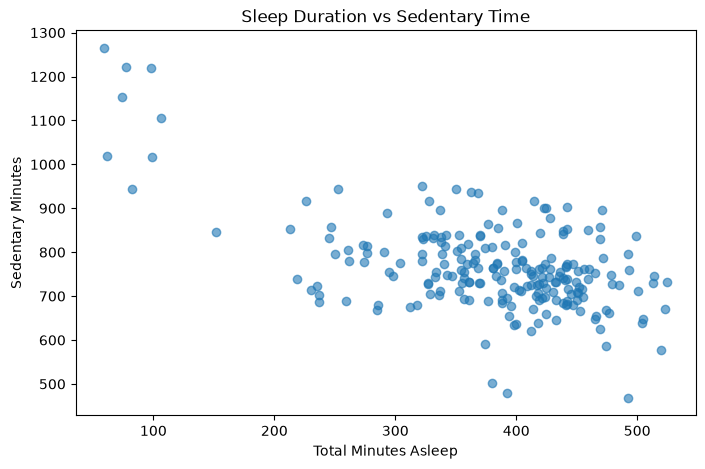

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sleep_activity_filtered["TotalMinutesAsleep"],
    sleep_activity_filtered["SedentaryMinutes"],
    alpha=0.6
)

plt.title("Sleep Duration vs Sedentary Time")
plt.xlabel("Total Minutes Asleep")
plt.ylabel("Sedentary Minutes")

plt.show()

### Sleep Duration and Sedentary Time

The scatter plot shows a moderate negative relationship between total minutes asleep and sedentary minutes, with a correlation of approximately -0.58.

In the matched dataset, records with longer sleep duration generally tended to contain fewer sedentary minutes.

However, this relationship should be interpreted cautiously. Sleep time and sedentary time both occupy portions of the same 24-hour period, so part of the negative association may reflect the limited number of minutes available within a day rather than a direct behavioural effect.

Therefore, the analysis does not establish that longer sleep causes lower sedentary behaviour.

The relationship is descriptive and may also be affected by differences between individual users and by how Fitbit assigns sleep and activity records to calendar dates.

In [49]:
sleep_day["NextDayDate"] = sleep_day["SleepDay"] + pd.Timedelta(days=1)

In [50]:
next_day_sleep_activity = pd.merge(
    sleep_day,
    valid_activity,
    left_on=["Id", "NextDayDate"],
    right_on=["Id", "ActivityDate"],
    how="inner"
)

In [51]:
print("Matched next-day records:", next_day_sleep_activity.shape[0])
print("Users:", next_day_sleep_activity["Id"].nunique())

Matched next-day records: 253
Users: 24


In [52]:
next_day_records_per_user = (
    next_day_sleep_activity.groupby("Id").size()
)

print(
    "Minimum next-day matched records for one user:",
    next_day_records_per_user.min()
)

print(
    "Maximum next-day matched records for one user:",
    next_day_records_per_user.max()
)

Minimum next-day matched records for one user: 1
Maximum next-day matched records for one user: 22


In [53]:
print(
    "Users with at least 7 next-day matched records:",
    (next_day_records_per_user >= 7).sum()
)

Users with at least 7 next-day matched records: 16


In [54]:
eligible_next_day_users = next_day_records_per_user[
    next_day_records_per_user >= 7
].index

In [55]:
next_day_sleep_activity_filtered = next_day_sleep_activity[
    next_day_sleep_activity["Id"].isin(eligible_next_day_users)
].copy()

In [56]:
print("Matched next-day records:", next_day_sleep_activity_filtered.shape[0])
print("Users:", next_day_sleep_activity_filtered["Id"].nunique())

Matched next-day records: 228
Users: 16


In [57]:
next_day_sleep_steps_corr = next_day_sleep_activity_filtered[
    ["TotalMinutesAsleep", "TotalSteps"]
].corr()

next_day_sleep_steps_corr

,TotalMinutesAsleep,TotalSteps
TotalMinutesAsleep,1.000000,-0.055646
TotalSteps,-0.055646,1.000000


In [58]:
next_day_sleep_sedentary_corr = next_day_sleep_activity_filtered[
    ["TotalMinutesAsleep", "SedentaryMinutes"]
].corr()

next_day_sleep_sedentary_corr

,TotalMinutesAsleep,SedentaryMinutes
TotalMinutesAsleep,1.000000,-0.029911
SedentaryMinutes,-0.029911,1.000000


### Sleep and Following-Day Activity

To explore whether sleep duration was associated with behaviour on the following day, each sleep record was matched with the user's valid activity record for the next calendar date.

Only users with at least 7 matched next-day records were included. This resulted in 228 matched records from 16 users.

The correlation between sleep duration and next-day step count was approximately -0.06, indicating virtually no linear relationship.

The correlation between sleep duration and next-day sedentary time was approximately -0.03, also indicating virtually no linear relationship.

These findings suggest that, within this dataset, sleep duration alone was not strongly associated with either step count or sedentary time on the following day.

The much weaker next-day sleep-sedentary relationship also suggests that the stronger same-day negative correlation may partly reflect the fact that sleep and sedentary time occupy portions of the same 24-hour period.

These results are descriptive and should not be interpreted as evidence that sleep has no effect on physical activity.

In [59]:
next_day_sleep_calories_corr = next_day_sleep_activity_filtered[
    ["TotalMinutesAsleep", "Calories"]
].corr()

next_day_sleep_calories_corr

,TotalMinutesAsleep,Calories
TotalMinutesAsleep,1.00000,0.08228
Calories,0.08228,1.00000


The correlation between sleep duration and next-day calories burned was approximately 0.08, indicating only a very weak positive relationship.

Overall, sleep duration showed little linear association with next-day steps, sedentary time or calorie expenditure in the filtered dataset. This suggests that sleep duration alone does not explain substantial variation in following-day activity behaviour within this sample.

## Key Findings

The analysis identified several important patterns in Fitbit users' activity and sleep behaviour.

### Activity

- Across 756 sufficiently complete activity days, users averaged approximately 7,801 steps per day.
- Users recorded approximately 22 minutes of very active activity, 14 minutes of fairly active activity and 191 minutes of light activity per valid day.
- Average sedentary time was approximately 1,083 minutes per valid day.
- Tuesday had the highest average step count at approximately 8,257 steps.
- Sunday had the lowest average step count at approximately 6,627 steps and the highest average sedentary time.
- Daily steps and calories burned showed a moderate positive correlation of approximately 0.58.

### User Activity Segments

Among users with at least 14 valid activity days:

- 8 users were classified as Low Activity.
- 14 users were classified as Moderate Activity.
- 7 users were classified as High Activity.

High Activity users averaged approximately 12,914 daily steps and 45.5 very active minutes, while Low Activity users averaged approximately 3,162 daily steps and 4.4 very active minutes.

Sedentary time generally decreased as activity level increased.

### Sleep

- The cleaned sleep dataset contained 410 records from 24 users.
- Average sleep duration was approximately 419 minutes, or about 6 hours and 59 minutes.
- Median sleep duration was approximately 433 minutes.
- Average sleep efficiency was approximately 91.65%.
- Sunday had the highest average sleep duration at approximately 453 minutes.
- Thursday had the lowest average sleep duration at approximately 401 minutes.

### Sleep and Activity Relationships

For same-day matched sleep and activity records:

- Sleep duration showed almost no linear relationship with daily steps.
- Sleep duration had a moderate negative correlation with sedentary time, approximately -0.58.
- Sleep duration had a weak positive correlation with calories burned, approximately 0.24.

The same-day sleep-sedentary relationship should be interpreted cautiously because sleep and sedentary time both occupy portions of the same 24-hour period.

For following-day activity:

- Sleep duration and next-day steps had a correlation of approximately -0.06.
- Sleep duration and next-day sedentary time had a correlation of approximately -0.03.
- Sleep duration and next-day calories had a correlation of approximately 0.08.

Overall, sleep duration showed little linear association with following-day activity measures in this sample.

### Overall Interpretation

The strongest patterns in the dataset relate to differences in activity behaviour rather than strong sleep-to-next-day-activity relationships.

Users with higher average step counts generally recorded more very active minutes and less sedentary time.

The analysis also suggests that Bellabeat could benefit from focusing on personalised activity engagement, sedentary-time reduction and day-specific wellness messaging rather than assuming that sleep duration alone strongly predicts following-day activity.

In [62]:
import os

print(os.getcwd())
print(os.path.exists("../powerbi"))
print(os.path.exists("../powerbi/data"))

c:\Users\OLUWATOSIN OLUWASEUN\Downloads\bellabeat-wellness-analysis\notebooks
False
False


In [63]:
from pathlib import Path

project_root = Path.cwd().parent
powerbi_data_folder = project_root / "powerbi" / "data"

powerbi_data_folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_root)
print("Power BI data folder:", powerbi_data_folder)
print("Folder exists:", powerbi_data_folder.exists())

Project folder: c:\Users\OLUWATOSIN OLUWASEUN\Downloads\bellabeat-wellness-analysis
Power BI data folder: c:\Users\OLUWATOSIN OLUWASEUN\Downloads\bellabeat-wellness-analysis\powerbi\data
Folder exists: True


In [64]:
valid_activity.to_csv(
    powerbi_data_folder / "valid_activity.csv",
    index=False
)

In [65]:
print((powerbi_data_folder / "valid_activity.csv").exists())

True


In [66]:
sleep_day.to_csv(
    powerbi_data_folder / "sleep_day_analysis.csv",
    index=False
)

In [67]:
print((powerbi_data_folder / "sleep_day_analysis.csv").exists())

True


In [68]:
weekday_activity.to_csv(
    powerbi_data_folder / "weekday_activity_summary.csv"
)

In [69]:
print((powerbi_data_folder / "weekday_activity_summary.csv").exists())

True


In [70]:
sleep_weekday.to_csv(
    powerbi_data_folder / "sleep_weekday_summary.csv"
)

In [71]:
print((powerbi_data_folder / "sleep_weekday_summary.csv").exists())

True


In [72]:
activity_group_summary.to_csv(
    powerbi_data_folder / "activity_group_summary.csv"
)

In [73]:
print((powerbi_data_folder / "activity_group_summary.csv").exists())

True


In [74]:
next_day_sleep_activity_filtered.to_csv(
    powerbi_data_folder / "next_day_sleep_activity.csv",
    index=False
)

In [75]:
print((powerbi_data_folder / "next_day_sleep_activity.csv").exists())

True


In [76]:
for file in sorted(powerbi_data_folder.glob("*.csv")):
    print(file.name)

activity_group_summary.csv
next_day_sleep_activity.csv
sleep_day_analysis.csv
sleep_weekday_summary.csv
valid_activity.csv
weekday_activity_summary.csv
